<a href="https://colab.research.google.com/github/Maame-Pokuaa77/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


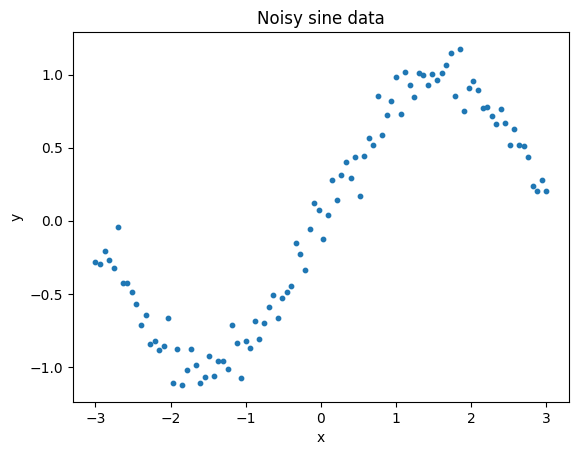

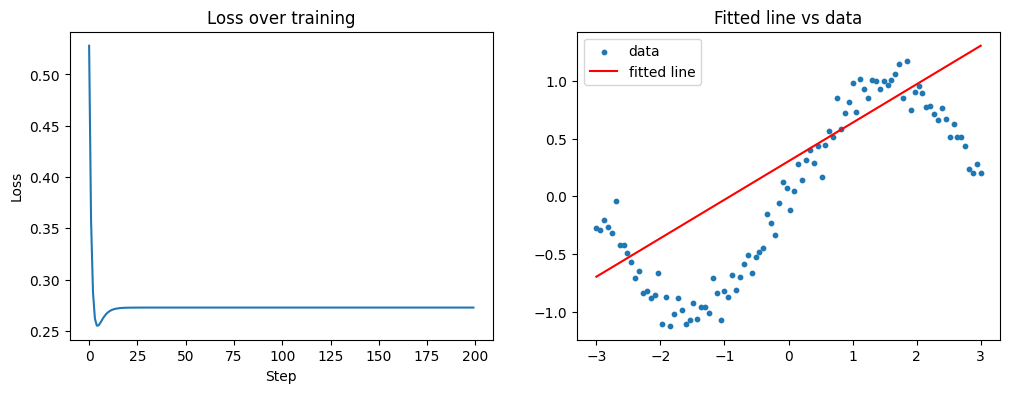

In [ ]:
#Part 1.1h
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)
#   Plot it.
plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Noisy sine data")
plt.show()

# TODO: Initialise w and b to small random values.
w= np.random.randn() * 0.1
b= np.random.randn() * 0.1
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.05
steps = 200
losses = []

for step in range(steps):

    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)               # MSE
    losses.append(loss)
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    = w - lr * dw
    b    = w - lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over training")

axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, w * x + b, color ="red", label="fitted line")
axes[1].legend()
axes[1].set_title("Fitted line vs data")

plt.show()



The Single Neuron

1.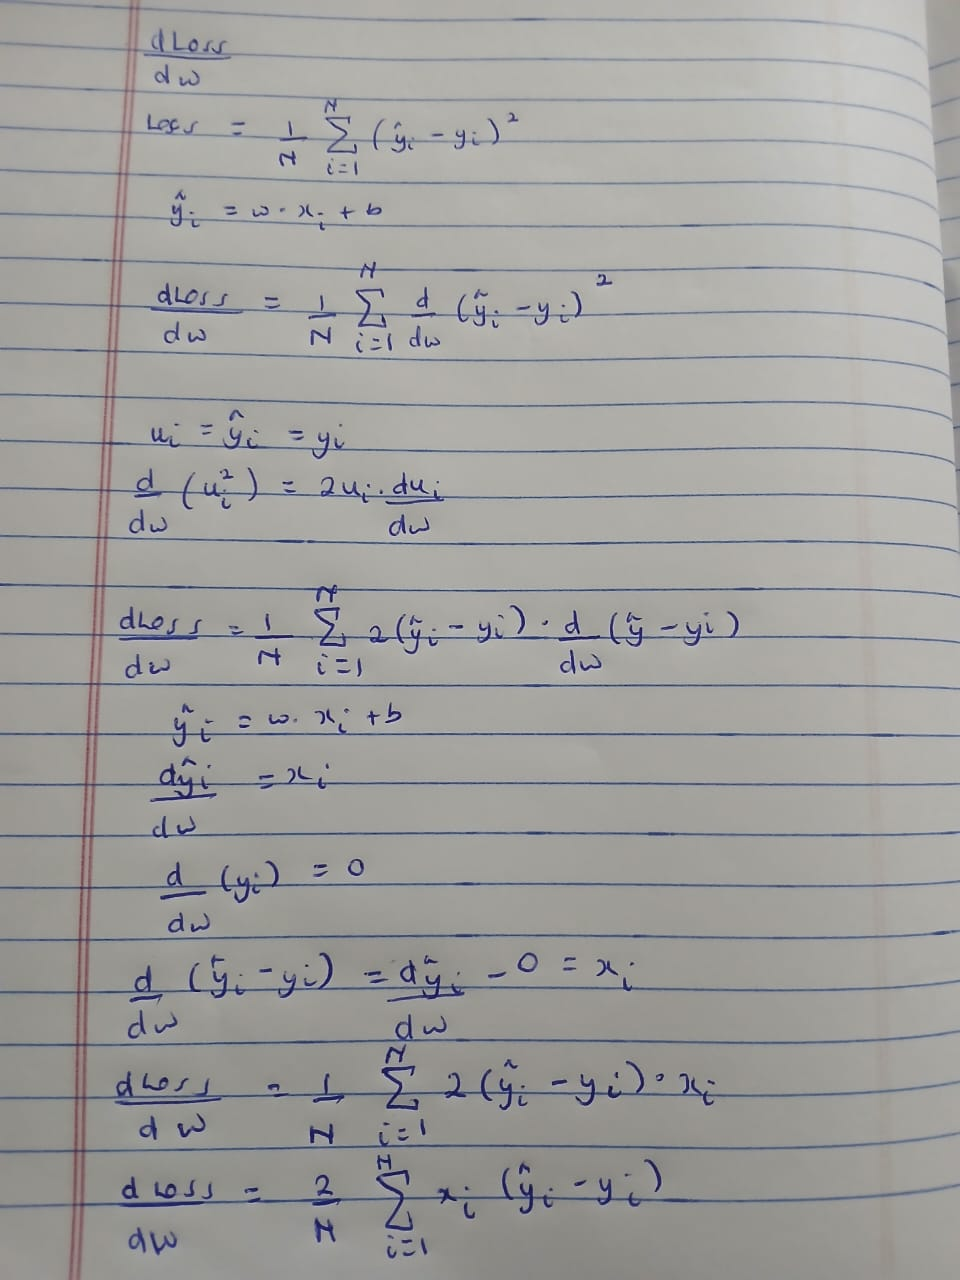


2.This is underfitting because from the image portraying the fitted line vs the data, the red line is failing to capture the training data's shape at all even though it's had 200 steps to try.A single neuron can't fit a sine wave because " y_hat = w·x + b"  describes a linear shape  no matter what values w and b take.

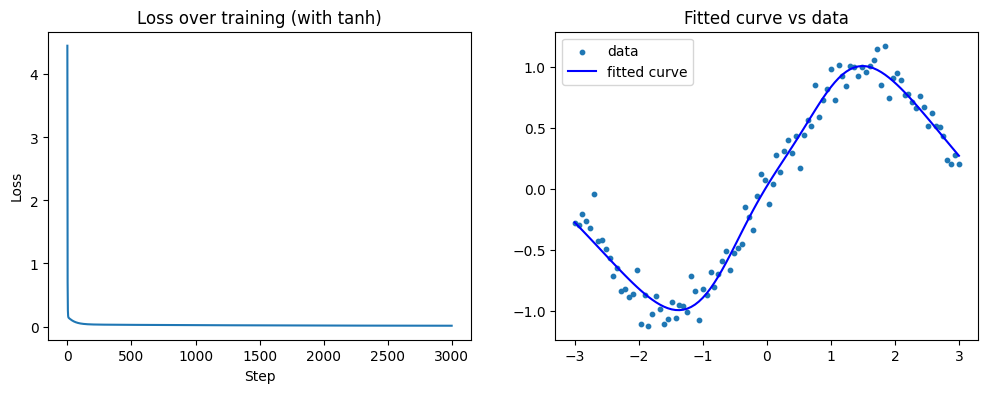

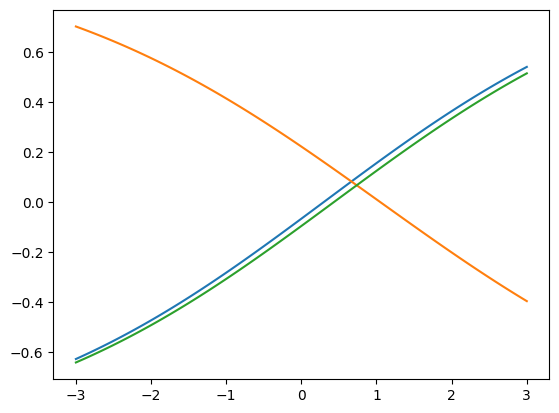

In [ ]:
#Part 1.2

# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

np.random.seed(RANDOM_STATE)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(1, 8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

# TODO: Forward pass (keep the intermediate values — you need them for backprop):


# TODO: Backward pass (the chain rule, layer by layer):


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.
lr = 0.05
steps= 3000
losses = []

for step in range(steps):

   #forward pass
   z1 = x_col @ W1 + b1
   h = np.tanh(z1)
   y_hat = h@ W2 + b2
   loss = np.mean((y_hat - y_col) ** 2)
   losses.append(loss)

   #backward pass
   d_yhat = 2 * (y_hat - y_col) / len(y_col)
   dW2 = h.T @ d_yhat
   db2 = d_yhat.sum(axis=0)
   dh = d_yhat @ W2.T
   dz1 = dh * (1 - np.tanh(z1) ** 2)
   dW1 = x_col.T @ dz1
   db1 = dz1.sum(axis=0)

   #Update
   W1 -= lr * dW1
   b1 -= lr * db1
   W2 -= lr * dW2
   b2 -= lr * db2




# TODO: Plot the loss curve AND the final fit over the data.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_title("Loss over training (with tanh)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")

axes[1].scatter(x, y, s=10, label="data")
axes[1].plot(x, y_hat, color="blue", label="fitted curve")
axes[1].legend()
axes[1].set_title("Fitted curve vs data")
plt.show()

plt.plot(x, h[:, 0])
plt.plot(x, h[:, 1])
plt.plot(x, h[:, 2])
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
h = z1



1. With tanh removed, the deep network fits no better than the single neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer.

Without tanh, each layer is just a linear equation (w·x + b). Substituting one layer's output into the next layer's input still only produces terms of the form (constant)·x + (constant) multiplying and adding straight-line equations together always gives another straight-line equation. So stacking many linear layers is mathematically no different from having just one; there's no way to introduce a bend without a non-linear function like tanh in between.

 2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.)

 Each of the hidden neurons produces its own tanh-shaped curve of x, but each one looks slightly different ;some rise, some fall, some are steeper or shifted compared to others, since each neuron has its own weight and bias. The output layer then combines these differently-shaped curves together (a weighted sum), and by mixing enough of these individual bends, the network can approximate the overall sine wave shape.

 3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?

 Backpropagation is when we navigate backwards through the steps we already took during the forward pass starting at the output layer, moving back through the tanh activation, and ending at the input layer  using the chain rule at each step to work out how much each parameter contributed to the error.

/tmp/ipykernel_831/2619637666.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_831/2619637666.py:30: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_831/2619637666.py:31: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


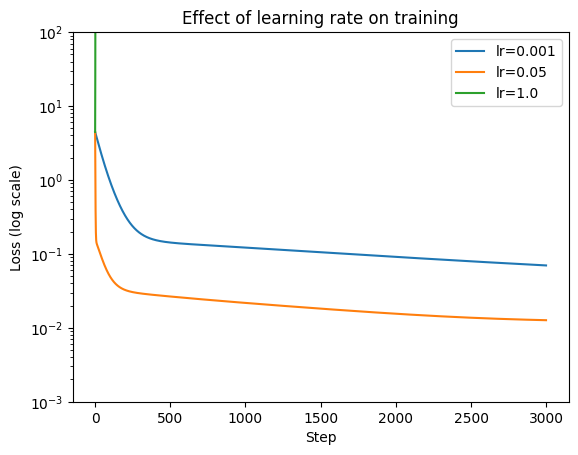

In [ ]:
#Part 1.3
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps = 3000):
  np.random.seed(RANDOM_STATE)


  W1 = np.random.randn(1, 8) * 0.5
  b1 = np.random.randn(1, 8) * 0.5

  W2 = np.random.randn(8, 1) * 0.5
  b2 = np.random.randn(1) * 0.5

  losses = []

  for step in range(steps):

   #forward pass
   z1 = x_col @ W1 + b1
   h = np.tanh(z1)
   y_hat = h@ W2 + b2
   loss = np.mean((y_hat - y_col) ** 2)
   losses.append(loss)

   #backward pass
   d_yhat = 2 * (y_hat - y_col) / len(y_col)
   dW2 = h.T @ d_yhat
   db2 = d_yhat.sum(axis=0)
   dh = d_yhat @ W2.T
   dz1 = dh * (1 - np.tanh(z1) ** 2)
   dW1 = x_col.T @ dz1
   db1 = dz1.sum(axis=0)

   #Update
   W1 -= lr * dW1
   b1 -= lr * db1
   W2 -= lr * dW2
   b2 -= lr * db2



  return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)
# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.plot(losses_low, label= "lr=0.001")
plt.plot(losses_mid, label= "lr=0.05")
plt.plot(losses_high, label= "lr=1.0")

plt.yscale("log")
plt.ylim(1e-3, 1e2)
plt.xlabel("Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of learning rate on training")
plt.legend()
plt.show()



 Describe what each of the three curves shows.
 The first curve with the learning rate (lr) of 0.001 has a slow but steady decline. The one with lr of 0.05 has a fast and stable convergence, and the one with lr of 1.0 has an explosive spike into extremely large values.

 Why does a too-large learning rate make the loss explode or oscillate instead of just "learning faster"?

 If the learning rate is too high, each update moves the weights too far in the downhill direction and overshoots the bottom of the loss curve, landing on the opposite slope instead , one that can be even steeper than where it started. Because the update size depends on both the learning rate and the gradient (lr × gradient), landing on a steeper slope means the next gradient is even bigger, which causes the next step to overshoot by an even larger amount. This creates a repeating cycle of overshoot to a  bigger gradient  and an even bigger overshoot, which is why the loss doesn't just "learn faster", it   explodes into extremely large values instead of settling smoothly toward the minimum like a small learning rate would.



In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", "cuda" if torch.cuda.is_available() else "cpu")

Running on: cpu


In [4]:
#Part 2.1
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

obesity = pd.read_csv(OBESITY_URL)
obesity.head()
# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

#(binary yes/no -> 0/1)

binary_map= {"yes": 1, "no": 0}

obesity["family_history_with_overweight"] = obesity["family_history_with_overweight"].map(binary_map)
obesity["FAVC"] = obesity["FAVC"].map(binary_map)
obesity["SMOKE"] = obesity["SMOKE"].map(binary_map)
obesity["SCC"] = obesity["SCC"].map(binary_map)


#Ordinal columns
ordinal_map = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}

obesity["CAEC"] = obesity["CAEC"].map(ordinal_map)
obesity["CALC"] = obesity["CALC"].map(ordinal_map)


#Nominal columns
obesity = pd.get_dummies(obesity, columns=["Gender", "MTRANS"], drop_first=True)


#engineer the BMI feature
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

#encode the target
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
obesity["NObeyesdad"] = target_encoder.fit_transform(obesity["NObeyesdad"])

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
from sklearn.model_selection import train_test_split

X = obesity.drop(columns=["NObeyesdad"])
y = obesity["NObeyesdad"]

# The test set (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

# The remaining 40% into validation (20%) and test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(X_train.shape, X_val.shape, X_test.shape)
# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests —
#    remember Section 1, where all gradients depended on x!)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
X_train_t = torch.tensor(X_train_scaled , dtype= torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled , dtype= torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)


X_test_t = torch.tensor(X_test_scaled , dtype= torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)


train_dataset = TensorDataset(X_train_t , y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)


train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 32 , shuffle=False)
test_loader = DataLoader(test_dataset, batch_size= 32, shuffle=False)

(1266, 20) (422, 20) (423, 20)


 1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

 CrossEntropyLoss computes a softmax over the output classes so it's easy to say the correct answer is a particular integer, say the answer is class 4, instead of saying it's a vector of 7 0s and a 1. Passing a one-hot vector would be redundant since a single integer already contains the same information.

 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

 2. Neural networks care so much about feature scaling because the gradient formulas depend directly on the raw feature value x (for example, dw = mean(2*(y_hat - y) * x)). If one feature like Weight ranges from 40-170 and another feature like CAEC ranges from 0-3, the Weight feature would produce much bigger gradients purely because of its larger scale, not because it's more important. This means the weights connected to large-scale features would get updated much faster than weights connected to small-scale features, making training unstable and unfair between features. A random forest doesn't have this problem because it makes decisions using threshold splits like "is Weight > 80?", and a split like that only cares about the order of the values, not their actual scale, so scaling makes no difference to how a tree splits the data.


  3. What does shuffle=True on the training DataLoader do, and why does it help?

   shuffle=True randomizes the order of the dataset so that in every batch and every epoch, the model sees a different mix of classes. Without shuffling, if the data happened to be sorted by class, the model would see one class for many batches in a row, then swiftly switch to the next class, repeating the exact same order every epoch. This could cause the model to start picking up on the fixed order of the data (like learning "batches early in an epoch are class 0, later batches are class 6") instead of learning the real relationship between the features and the labels. Shuffling breaks up this pattern so the model is forced to learn from the actual input features rather than memorizing position in the dataset.

